# 📓 7. Practical Jupyter Notebook — Standardization (StandardScaler)

## Cell 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

## Cell 2 — Create Dataset

In [2]:
data = {
    "age": [18, 20, 22, 25, 30, 35, 40],
    "salary": [20000, 25000, 30000, 45000, 60000, 90000, 150000],
    "experience": [0, 1, 2, 3, 5, 8, 12]
}

df = pd.DataFrame(data)

df

,age,salary,experience
0,18,20000,0
1,20,25000,1
2,22,30000,2
3,25,45000,3
4,30,60000,5
5,35,90000,8
6,40,150000,12


## Cell 3 — Check Dataset

In [3]:
print("----- First 5 Rows -----")
print(df.head())

print("\n----- Shape -----")
print(df.shape)

print("\n----- Data Types -----")
print(df.dtypes)

print("\n----- Statistical Summary -----")
print(df.describe())

----- First 5 Rows -----
   age  salary  experience
0   18   20000           0
1   20   25000           1
2   22   30000           2
3   25   45000           3
4   30   60000           5

----- Shape -----
(7, 3)

----- Data Types -----
age           int64
salary        int64
experience    int64
dtype: object

----- Statistical Summary -----
             age         salary  experience
count   7.000000       7.000000    7.000000
mean   27.142857   60000.000000    4.428571
std     8.173709   46457.866216    4.276180
min    18.000000   20000.000000    0.000000
25%    21.000000   27500.000000    1.500000
50%    25.000000   45000.000000    3.000000
75%    32.500000   75000.000000    6.500000
max    40.000000  150000.000000   12.000000


Yahan notice karo:

- age → small values
- salary → large values
- experience → different scale

## Cell 4 — Check Mean and Standard Deviation

In [4]:
print("Mean:")
print(df.mean())

print("\nStandard Deviation:")
print(df.std())

Mean:
age              27.142857
salary        60000.000000
experience        4.428571
dtype: float64

Standard Deviation:
age               8.173709
salary        46457.866216
experience        4.276180
dtype: float64


Abhi features ka mean 0 nahi hai aur standard deviation 1 nahi hai.

## Cell 5 — Visualize Before Standardization

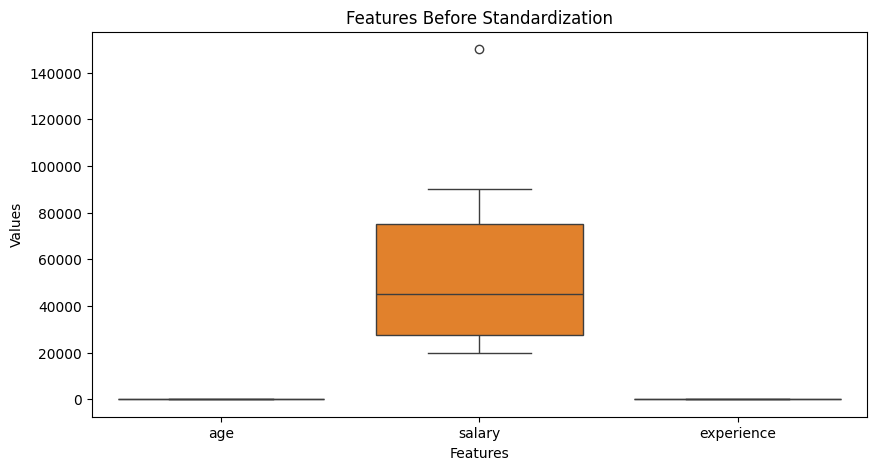

In [5]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df)

plt.title("Features Before Standardization")
plt.xlabel("Features")
plt.ylabel("Values")

plt.show()

## Cell 6 — Create StandardScaler

In [6]:
scaler = StandardScaler()

print(scaler)

StandardScaler()


## Cell 7 — Apply Standardization

In [7]:
df_standardized = scaler.fit_transform(df)

df_standardized

array([[-1.20819251, -0.92998111, -1.11861615],
       [-0.9439004 , -0.81373347, -0.8660254 ],
       [-0.67960829, -0.69748583, -0.61343466],
       [-0.28317012, -0.34874292, -0.36084392],
       [ 0.37756016,  0.        ,  0.14433757],
       [ 1.03829044,  0.69748583,  0.9021098 ],
       [ 1.69902072,  2.0924575 ,  1.91247277]])

`fit_transform()` do kaam karta hai:

- **fit** → Mean aur Standard Deviation learn
- **transform** → Formula apply

## Cell 8 — Convert Result into DataFrame

In [8]:
df_standardized = pd.DataFrame(
    df_standardized,
    columns=df.columns
)

df_standardized

,age,salary,experience
0,-1.208193,-0.929981,-1.118616
1,-0.943900,-0.813733,-0.866025
2,-0.679608,-0.697486,-0.613435
3,-0.283170,-0.348743,-0.360844
4,0.377560,0.000000,0.144338
5,1.038290,0.697486,0.902110
6,1.699021,2.092457,1.912473


Ab values approximately: age → around -1 to +1, salary → around -1 to +2, experience → around -1 to +1 hongi. Exact values dataset ke according calculate hongi.

## Cell 9 — Check Mean After Standardization

In [9]:
print("Mean after Standardization:")

print(df_standardized.mean())

Mean after Standardization:
age           1.268826e-16
salary       -6.344132e-17
experience   -9.516197e-17
dtype: float64


Expected: age ≈ 0, salary ≈ 0, experience ≈ 0

## Cell 10 — Check Standard Deviation

In [10]:
print("Standard Deviation after Standardization (pandas default, ddof=1):")
print(df_standardized.std())

print("\nStandard Deviation after Standardization (population, ddof=0):")
print(df_standardized.std(ddof=0))

Standard Deviation after Standardization (pandas default, ddof=1):
age           1.080123
salary        1.080123
experience    1.080123
dtype: float64

Standard Deviation after Standardization (population, ddof=0):
age           1.0
salary        1.0
experience    1.0
dtype: float64


⚠️ Pandas ka `.std()` default **sample** standard deviation calculate karta hai, isliye exact 1 ke bajay slightly different value aati hai. `StandardScaler` **population** std (`ddof=0`) use karta hai, isliye `ddof=0` wale output mein teeno ≈ 1 aayenge.

## Cell 11 — Compare Original vs Standardized

In [11]:
comparison = pd.DataFrame({
    "Original Age": df["age"],
    "Standardized Age": df_standardized["age"],

    "Original Salary": df["salary"],
    "Standardized Salary": df_standardized["salary"],

    "Original Experience": df["experience"],
    "Standardized Experience": df_standardized["experience"]
})

comparison

,Original Age,Standardized Age,Original Salary,Standardized Salary,Original Experience,Standardized Experience
0,18,-1.208193,20000,-0.929981,0,-1.118616
1,20,-0.943900,25000,-0.813733,1,-0.866025
2,22,-0.679608,30000,-0.697486,2,-0.613435
3,25,-0.283170,45000,-0.348743,3,-0.360844
4,30,0.377560,60000,0.000000,5,0.144338
5,35,1.038290,90000,0.697486,8,0.902110
6,40,1.699021,150000,2.092457,12,1.912473


## Cell 12 — Verify Formula Manually

Salary ke liye manually calculate karte hain.

In [12]:
salary_mean = df["salary"].mean()
salary_std = df["salary"].std(ddof=0)

df["salary_manual"] = (df["salary"] - salary_mean) / salary_std

manual_vs_sklearn = pd.DataFrame({
    "Original Salary": df["salary"],
    "Manual Standardization": df["salary_manual"],
    "Sklearn Standardization": df_standardized["salary"]
})

manual_vs_sklearn

,Original Salary,Manual Standardization,Sklearn Standardization
0,20000,-0.929981,-0.929981
1,25000,-0.813733,-0.813733
2,30000,-0.697486,-0.697486
3,45000,-0.348743,-0.348743
4,60000,0.000000,0.000000
5,90000,0.697486,0.697486
6,150000,2.092457,2.092457


In [13]:
print("Manual and sklearn same hain?", np.allclose(df["salary_manual"], df_standardized["salary"]))

Manual and sklearn same hain? True


## Cell 13 — Visualization After Standardization

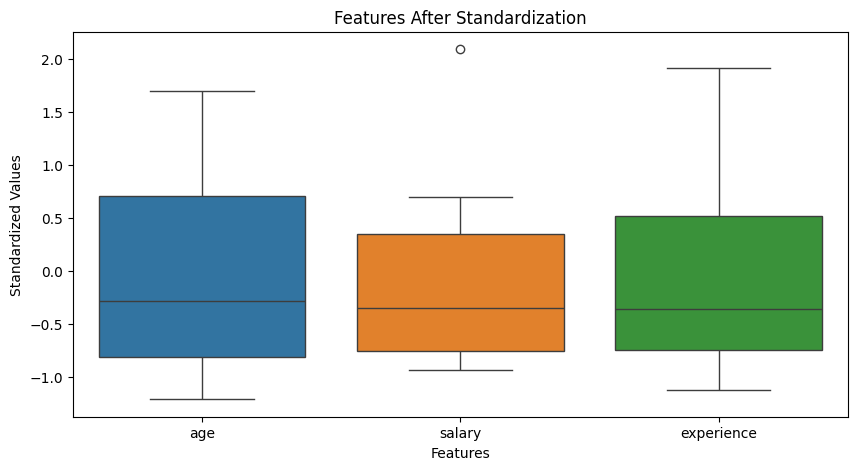

In [14]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df_standardized)

plt.title("Features After Standardization")
plt.xlabel("Features")
plt.ylabel("Standardized Values")

plt.show()

Ab teeno features comparable scale par hain.

## 🎮 Bonus — Interactive Z-Score Graph (Game Mode)

Sliders ko hilao aur dekho:

- **x** = value, **μ** = mean, **σ** = standard deviation
- Graph mein blue shaded area = **Φ(z)** (x se neeche kitni values hain, percentile)
- Neeche ek mini challenge bhi hai

*(Sliders sirf live Jupyter / VS Code / Colab mein kaam karte hain, static preview mein nahi.)*

$$ z = \frac{x-\mu}{\sigma} $$

In [15]:
import ipywidgets as widgets
from math import erf, sqrt

def phi(z):
    return 0.5 * (1 + erf(z / sqrt(2)))

def z_score_graph(x=1.2, mu=0.0, sigma=1.0):
    z = (x - mu) / sigma
    xs = np.linspace(-10, 10, 800)
    ys = np.exp(-0.5 * ((xs - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(xs, ys, color="#3b82f6", lw=2)
    ax.fill_between(xs, ys, where=xs <= x, color="#3b82f6", alpha=0.3)
    ax.axvline(mu, color="gray", ls="--", label=f"μ = {mu:.1f}")
    ax.axvline(x, color="tomato", lw=2, label=f"x = {x:.1f}")
    ax.set_title(f"z = ({x:.1f} - {mu:.1f}) / {sigma:.1f} = {z:.2f}     Φ(z) ≈ {phi(z)*100:.1f}%")
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend()
    plt.show()

widgets.interact(
    z_score_graph,
    x=widgets.FloatSlider(value=1.2, min=-8, max=8, step=0.1, description="x"),
    mu=widgets.FloatSlider(value=0.0, min=-5, max=5, step=0.1, description="μ"),
    sigma=widgets.FloatSlider(value=1.0, min=0.5, max=5, step=0.1, description="σ"),
);

interactive(children=(FloatSlider(value=1.2, description='x', max=8.0, min=-8.0), FloatSlider(value=0.0, descr…

### 🎯 Mini Challenge — Percentile Hit Karo

Target percentile diya jayega. `x` slider ko aise set karo ki Φ(z) target ke ±2% ke andar aa jaye (μ = 0, σ = 1 fixed).

Pehle `Naya Challenge` dabao, phir slider hilao.

In [16]:
import random

state = {"target": random.choice([10, 25, 50, 75, 84, 90, 95, 97.5]), "score": 0}

target_label = widgets.HTML()
result_label = widgets.HTML()
guess_slider = widgets.FloatSlider(value=0, min=-3.5, max=3.5, step=0.05, description="x", layout=widgets.Layout(width="450px"))
new_btn = widgets.Button(description="Naya Challenge", button_style="info")

def show_target():
    target_label.value = f"<b>🎯 Target: {state['target']}th percentile</b> &nbsp;|&nbsp; Score: {state['score']}"

def check(change=None):
    z = guess_slider.value
    p = phi(z) * 100
    hit = abs(p - state["target"]) <= 2
    result_label.value = f"z = {z:.2f} → Φ(z) = {p:.1f}% " + ("✅ HIT!" if hit else "❌ thoda aur try karo")
    if hit and change is not None and not getattr(check, "scored", False):
        state["score"] += 1
        check.scored = True
        show_target()

def new_challenge(_):
    state["target"] = random.choice([10, 25, 50, 75, 84, 90, 95, 97.5])
    check.scored = False
    show_target()
    check()

guess_slider.observe(check, names="value")
new_btn.on_click(new_challenge)
show_target(); check()
display(widgets.VBox([target_label, guess_slider, result_label, new_btn]))

### 🕹️ Web-Style Z-Score Game (har Jupyter mein chalega)

Ye wahi game hai jo web page version mein hai: sliders, live formula, Φ(z) shaded graph aur percentile challenge. Ye `ipywidgets` ke bina bhi chalta hai (HTML + JavaScript iframe).

In [17]:
from IPython.display import HTML, display
import html as _html

game_html = r"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1, viewport-fit=cover">
<title>Z-Score Game</title>
<style>
:root{--bg:#f6f7f9;--card:#fff;--fg:#1a1d21;--mut:#6b7280;--acc:#3b82f6;--ok:#16a34a;--bad:#dc2626;--line:#d9dde3;box-sizing:border-box;padding-top:env(safe-area-inset-top,0px);padding-bottom:env(safe-area-inset-bottom,0px)}
@media (prefers-color-scheme:dark){:root:not([data-theme="light"]){--bg:#111214;--card:#1f2023;--fg:#f1f2f4;--mut:#9aa0a8;--line:#35373c}}
:root[data-theme="dark"]{--bg:#111214;--card:#1f2023;--fg:#f1f2f4;--mut:#9aa0a8;--line:#35373c}
html{scroll-padding-top:env(safe-area-inset-top,0px)}
body{margin:0;background:var(--bg);color:var(--fg);font-family:system-ui,-apple-system,"Segoe UI",sans-serif;padding:16px}
.card{max-width:760px;margin:0 auto;background:var(--card);border:1px solid var(--line);border-radius:16px;padding:18px}
h1{font-size:1.15rem;margin:0 0 10px}
.formula{text-align:center;font-size:1.15rem;margin:10px 0;font-family:Georgia,serif}
.formula b{font-size:1.35rem}
canvas{width:100%;height:220px;display:block;border-radius:10px;background:var(--bg)}
.row{display:flex;align-items:center;gap:10px;margin:10px 0}
.row label{width:28px;font-family:Georgia,serif;font-style:italic}
.row output{width:44px;text-align:right;font-variant-numeric:tabular-nums}
input[type=range]{flex:1;accent-color:var(--acc)}
.game{margin-top:14px;padding-top:14px;border-top:1px solid var(--line)}
.target{font-size:1.05rem;font-weight:600}
.msg{min-height:1.4em;margin:6px 0;color:var(--mut)}
.msg.ok{color:var(--ok)}.msg.bad{color:var(--bad)}
button{background:var(--acc);color:#fff;border:0;border-radius:10px;padding:10px 16px;font-size:.95rem;cursor:pointer}
.stats{color:var(--mut);font-size:.9rem;margin-left:10px}
</style>
</head>
<body>
<div class="card">
  <h1>🎮 Z-Score Game</h1>
  <div class="formula" id="f1">z = (x − μ) / σ</div>
  <div class="formula" id="f2"></div>
  <canvas id="cv" width="720" height="220"></canvas>
  <div class="row"><label>x</label><input id="x" type="range" min="-8" max="8" step="0.1" value="1.2"><output id="xo"></output></div>
  <div class="row"><label>μ</label><input id="mu" type="range" min="-5" max="5" step="0.1" value="0"><output id="muo"></output></div>
  <div class="row"><label>σ</label><input id="sg" type="range" min="0.5" max="5" step="0.1" value="1"><output id="sgo"></output></div>

  <div class="game">
    <div class="target" id="target"></div>
    <div class="msg" id="msg">Move x so that Φ(z) lands within ±2% of the target.</div>
    <button id="new">New challenge</button><span class="stats" id="stats"></span>
  </div>
</div>
<script>
const $=id=>document.getElementById(id);
const cv=$("cv"),ctx=cv.getContext("2d");
function erf(x){const s=Math.sign(x);x=Math.abs(x);const t=1/(1+0.3275911*x);
  const y=1-(((((1.061405429*t-1.453152027)*t)+1.421413741)*t-0.284496736)*t+0.254829592)*t*Math.exp(-x*x);return s*y}
const phi=z=>0.5*(1+erf(z/Math.SQRT2));
const targets=[10,25,50,75,84,90,95,97.5];
let target=50,score=0,tries=0,scored=false;
function css(v){return getComputedStyle(document.documentElement).getPropertyValue(v).trim()}
function draw(){
  const x=+$("x").value,mu=+$("mu").value,sg=+$("sg").value,z=(x-mu)/sg,p=phi(z)*100;
  $("xo").textContent=x.toFixed(1);$("muo").textContent=mu.toFixed(1);$("sgo").textContent=sg.toFixed(1);
  $("f2").innerHTML="z = ("+x.toFixed(1)+" − "+mu.toFixed(1)+") / "+sg.toFixed(1)+" = <b>"+z.toFixed(2)+"</b><br>Φ(z) ≈ <b>"+p.toFixed(1)+"%</b>";
  const W=cv.width,H=cv.height,pad=20,lo=-10,hi=10;
  const X=v=>pad+(v-lo)/(hi-lo)*(W-2*pad);
  const pdf=v=>Math.exp(-0.5*((v-mu)/sg)**2)/(sg*Math.sqrt(2*Math.PI));
  const ymax=pdf(mu),Y=v=>H-pad-(v/ymax)*(H-2*pad-20);
  ctx.clearRect(0,0,W,H);
  ctx.strokeStyle=css("--line");ctx.beginPath();ctx.moveTo(pad,H-pad);ctx.lineTo(W-pad,H-pad);ctx.stroke();
  ctx.beginPath();ctx.moveTo(X(lo),H-pad);
  for(let v=lo;v<=Math.min(x,hi);v+=0.05)ctx.lineTo(X(v),Y(pdf(v)));
  ctx.lineTo(X(Math.min(x,hi)),H-pad);ctx.closePath();ctx.fillStyle="rgba(59,130,246,.3)";ctx.fill();
  ctx.beginPath();for(let v=lo;v<=hi;v+=0.05){const px=X(v),py=Y(pdf(v));v===lo?ctx.moveTo(px,py):ctx.lineTo(px,py)}
  ctx.strokeStyle="#3b82f6";ctx.lineWidth=2.5;ctx.stroke();
  ctx.lineWidth=1.5;ctx.setLineDash([5,4]);ctx.strokeStyle="#9aa0a8";ctx.beginPath();ctx.moveTo(X(mu),10);ctx.lineTo(X(mu),H-pad);ctx.stroke();ctx.setLineDash([]);
  ctx.strokeStyle="#ef4444";ctx.lineWidth=2;ctx.beginPath();ctx.moveTo(X(x),10);ctx.lineTo(X(x),H-pad);ctx.stroke();
  ctx.font="13px system-ui";ctx.fillStyle="#9aa0a8";ctx.fillText("μ",X(mu)+4,18);ctx.fillStyle="#ef4444";ctx.fillText("x",X(x)+4,34);
  check(p);
}
function check(p){
  const m=$("msg");
  if(Math.abs(p-target)<=2){m.textContent="✅ HIT! Φ(z) = "+p.toFixed(1)+"%";m.className="msg ok";
    if(!scored){scored=true;score++;tries++}}
  else{m.textContent=(p<target?"⬆ Too low":"⬇ Too high")+" — Φ(z) = "+p.toFixed(1)+"%";m.className="msg bad"}
  $("stats").textContent="Score: "+score;
}
function newChallenge(){target=targets[Math.floor(Math.random()*targets.length)];scored=false;
  $("target").textContent="🎯 Target: "+target+"th percentile";draw()}
["x","mu","sg"].forEach(id=>$(id).addEventListener("input",draw));
$("new").addEventListener("click",newChallenge);
window.addEventListener("resize",draw);
newChallenge();
</script>
</body>
</html>
"""

display(HTML(
    '<iframe srcdoc="' + _html.escape(game_html, quote=True) + '" '
    'width="100%" height="640" style="border:0;border-radius:12px;"></iframe>'
))

/usr/local/lib/python3.12/dist-packages/IPython/core/display.py:448: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


## Cell 14 — Train-Test Split

Real ML project mein pehle dataset split karna chahiye.

In [18]:
from sklearn.model_selection import train_test_split

X = df[["age", "salary", "experience"]]

X_train, X_test = train_test_split(
    X,
    test_size=0.2,
    random_state=42
)

print("Training Data:")
print(X_train)

print("\nTesting Data:")
print(X_test)

Training Data:
   age  salary  experience
5   35   90000           8
2   22   30000           2
4   30   60000           5
3   25   45000           3
6   40  150000          12

Testing Data:
   age  salary  experience
0   18   20000           0
1   20   25000           1


## Cell 15 — Correct Standardization

In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

**Important:**

- `scaler.fit_transform(X_train)` → Training data se Mean aur Standard Deviation learn karega.
- `scaler.transform(X_test)` → Test data par wahi learned parameters apply honge.

## Cell 16 — Convert Train/Test into DataFrame

In [20]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

print("Scaled Training Data:")
print(X_train_scaled)

print("\nScaled Testing Data:")
print(X_test_scaled)

Scaled Training Data:
        age    salary  experience
5  0.704448  0.353553    0.550482
2 -1.286384 -1.060660   -1.100964
4 -0.061256 -0.353553   -0.275241
3 -0.826961 -0.707107   -0.825723
6  1.470153  1.767767    1.651446

Scaled Testing Data:
        age    salary  experience
0 -1.898948 -1.296362   -1.651446
1 -1.592666 -1.178511   -1.376205


## Cell 17 — Save Standardized Dataset

In [21]:
df_standardized.to_csv(
    "standardized_data.csv",
    index=False
)

print("Standardized dataset saved successfully!")

Standardized dataset saved successfully!


## 🧠 Final Revision

```
Standardization
Original Data
     ↓
Calculate Mean
     ↓
Calculate Standard Deviation
     ↓
(x - Mean) / Standard Deviation
     ↓
Standardized Data
```

**Target:** Mean ≈ 0, Standard Deviation ≈ 1

**Formula:**

$$ z = \frac{x-\mu}{\sigma} $$

**Python:**

```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
```

## 🧠 Ek line mein yaad rakho:

**Standardization = Mean ko 0 aur Standard Deviation ko 1 ke around lana.**